## Исследовательский анализ данных о ДТП

Цель: посчитать и проанализировать статистические показатели ДТП за период 2015-2025 гг. Посмотреть и оценить влияние погодных условий на количество ДТП. Выявить иные факторы и аномалии при наличии.  Для анализа выбраны два города г. Екатеринбург и г. Владивосток. Выбор городов обусловлен разностью их климата. В Екатеринбурге климат умеренно-континентальный с резкими колебаниями температур и выраженными сезонами. Во Владивостоке климат умеренный муссонный с ярко выраженными сезонами и  высокой влажностью из-за близости океана. 

План работ:
- выгрузка данных из БД/csv
- анализ основной стастистики по ДТП, в т.ч. в динамике, построение графиков
- выявление взаимосвязи количества ДТП с погодными условиями
- категоризация данных, расчет корреляции
- проверка гипотез

In [1]:
# импорт библиотек
import time
from datetime import datetime, timedelta
from typing import List, Dict, Optional

import pandas as pd
import numpy as np

import sqlalchemy
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [2]:
# Подключение к БД Supabase
load_dotenv()

# Параметры подключения
user = os.getenv('user')
password = os.getenv('password')
host = os.getenv('host')
port = '6543'
dbname = os.getenv('dbname')

# Адрес подключения
DATABASE_URL = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}?sslmode=require"

# Формируем движок
engine = create_engine(DATABASE_URL) 

try:
    with engine.connect() as connection:
        print(f'Подключение к базе успешно')
except Exception as e:
        print(f'Ошибка при подключении к базе: {e}')

Ошибка при подключении к базе: (psycopg2.OperationalError) server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.
server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.

[SQL: select pg_catalog.version()]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


### 1. Основная статистика по ДТП

Выгружаем данные из БД, при невозможности подключения  - из резервного источника csv

In [3]:
try:
    query_main = '''
           SELECT *
           FROM main_clean;
          '''
    main_clean = pd.read_sql_query(query_main, con=engine)

except: 
    main_clean = pd.read_csv('main_clean.csv')

In [4]:
main_clean.info()
main_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19627 entries, 0 to 19626
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   KartId           19627 non-null  int64  
 1   date             19627 non-null  object 
 2   time             19627 non-null  object 
 3   district         19627 non-null  object 
 4   dtp_type         19627 non-null  object 
 5   dead             19627 non-null  int64  
 6   injured          19627 non-null  int64  
 7   ts_quantity      19627 non-null  int64  
 8   people_quantity  19627 non-null  int64  
 9   year             19627 non-null  int64  
 10  month            19627 non-null  int64  
 11  day              19627 non-null  int64  
 12  city             19627 non-null  object 
 13  population       19627 non-null  float64
dtypes: float64(1), int64(8), object(5)
memory usage: 2.1+ MB


,KartId,date,time,district,dtp_type,dead,injured,ts_quantity,people_quantity,year,month,day,city,population
0,157114292,2015-01-02,12:30,Верх-Исетский,Наезд на стоящее ТС,0,1,2,3,2015,1,2,Екатеринбург,1544376.0
1,157122648,2015-01-02,17:15,Кировский,Наезд на пешехода,0,2,1,3,2015,1,2,Екатеринбург,1544376.0
2,157156173,2015-01-01,22:00,Октябрьский,Наезд на препятствие,0,1,1,1,2015,1,1,Екатеринбург,1544376.0
3,157223255,2015-01-01,02:20,Первомайский,Столкновение,0,2,2,3,2015,1,1,Владивосток,603519.0
4,157225233,2015-01-01,14:30,Первореченский,Наезд на пешехода,0,1,1,2,2015,1,1,Владивосток,603519.0


In [5]:
main_clean['date'] = pd.to_datetime(main_clean['date'])
# добавим день недели
main_clean['weekday'] = main_clean['date'].dt.dayofweek+1

**Поскольку данные приведены только о днях когда было официально зафиксировано хоть 1 ДТП, то проверим были ли дни без ДТП**

In [6]:
# количество календарных дней за период 2015-2025
print(main_clean['date'].max())
print(main_clean['date'].min())

start_date = datetime(2015, 1, 1)
end_date = datetime(2025, 12, 31)

# Разница в днях
delta = end_date - start_date
total_days = delta.days + 1 
print('всего дней:', total_days)

2025-12-31 00:00:00
2015-01-01 00:00:00
всего дней: 4018


In [7]:
dekb = main_clean.loc[main_clean['city']=='Екатеринбург']
print(f"количество дней с ДТП за период 2015-2025 в Екб: {dekb['date'].nunique()}")
print(f"количество дней без ДТП: {total_days - dekb['date'].nunique()}")

dvlad = main_clean.loc[main_clean['city']=='Владивосток']
print(f"количество дней с ДТП за период 2015-2025 в Владивосток: {dvlad['date'].nunique()}")
print(f"количество дней без ДТП: {total_days - dvlad['date'].nunique()}")

количество дней с ДТП за период 2015-2025 в Екб: 3584
количество дней без ДТП: 434
количество дней с ДТП за период 2015-2025 в Владивосток: 3523
количество дней без ДТП: 495


**Вывод почти 90% дней - происходит хоть 1 ДТП**

In [8]:
try:
    query_info_dtp = '''
           SELECT *
           FROM info_dtp_clean;
          '''
    info_dtp_clean = pd.read_sql_query(query_info_dtp, con=engine)

except: 
    info_dtp_clean = pd.read_csv('info_dtp_clean.csv')
    

In [9]:
info_dtp_clean.info()
info_dtp_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19627 entries, 0 to 19626
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   KartId             19627 non-null  int64 
 1   city               19627 non-null  object
 2   street_category    18808 non-null  object
 3   road_category      19627 non-null  object
 4   road_coverage      19627 non-null  object
 5   light              19627 non-null  object
 6   change_org_motion  19627 non-null  object
 7   road_problems      19627 non-null  object
 8   scheme             19627 non-null  object
 9   factor             19627 non-null  object
 10  weather            19627 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.6+ MB


,KartId,city,street_category,road_category,road_coverage,light,change_org_motion,road_problems,scheme,factor,weather
0,161237026,Екатеринбург,Улицы и дороги местного значения в жилой застр...,Не указано,Сухое,Светлое время суток,Режим движения не изменялся,Недостатки зимнего содержания,Перегон (нет объектов на месте ДТП),Сведения отсутствуют,Ясно
1,161340310,Екатеринбург,Улицы и дороги местного значения в жилой застр...,Не указано,Сухое,Светлое время суток,Режим движения не изменялся,Не установлены,"Перегон (нет объектов на месте ДТП), Автостоян...",Сведения отсутствуют,Ясно
2,161238027,Екатеринбург,Магистральные улицы районного значения,Не указано,Обработанное противогололедными материалами,"В темное время суток, освещение включено",Режим движения не изменялся,"Отсутствие, плохая различимость горизонтальной...",Перегон (нет объектов на месте ДТП),Сведения отсутствуют,Пасмурно
3,171517613,Екатеринбург,Магистральные улицы районного значения,Не указано,Гололедица,"В темное время суток, освещение включено",Режим движения не изменялся,Нарушения в размещении наружной рекламы,"Регулируемый пешеходный переход, Регулируемый ...",Сведения отсутствуют,Ясно
4,160935023,Екатеринбург,Магистральные улицы районного значения,Не указано,Сухое,"В темное время суток, освещение включено",Движение частично перекрыто,"Отсутствие, плохая различимость горизонтальной...","Перегон (нет объектов на месте ДТП), Регулируе...",Сведения отсутствуют,Пасмурно


### Сравним данные по двум городам на графиках

In [10]:
def time_line_plot(df:pd.DataFrame, feature: str, time:str):
    ''' Строит линейный график количества ДТП или количества погибших/раненых 
    в разбивке по городам и  выбранному по временному периоду'''
    
    if feature == 'KartId':     
        result = (df.groupby(['city', time])
              .agg(count=(feature, 'count'))
              .reset_index())
    else:
        result = (df.groupby(['city', time])
              .agg(count=(feature, 'sum'))
              .reset_index())
    
    pivot_df = result.pivot(index=time, columns='city', values='count')
    pivot_df.plot(kind='line', figsize=(12, 6), marker='o')

    plt.title(f'Динамика количества {feature} по {time}', fontsize=12)
    plt.xlabel(f'{time}', fontsize=10)
    plt.ylabel(f'{feature}', fontsize=10)
    plt.legend(title='Город', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True, alpha=0.3)
    

    plt.show()

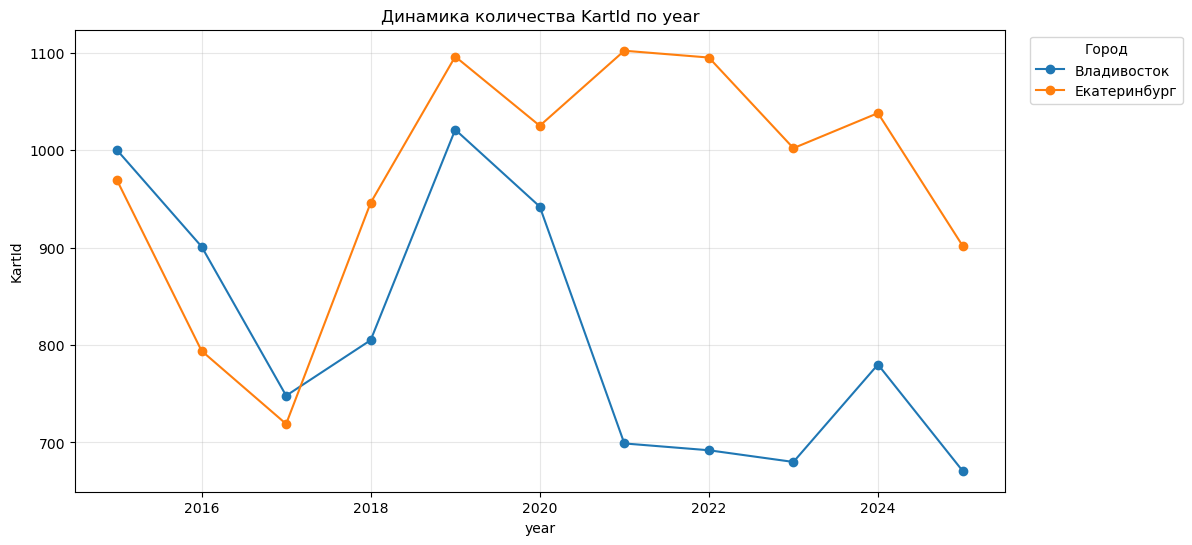

In [11]:
time_line_plot(main_clean, 'KartId','year')

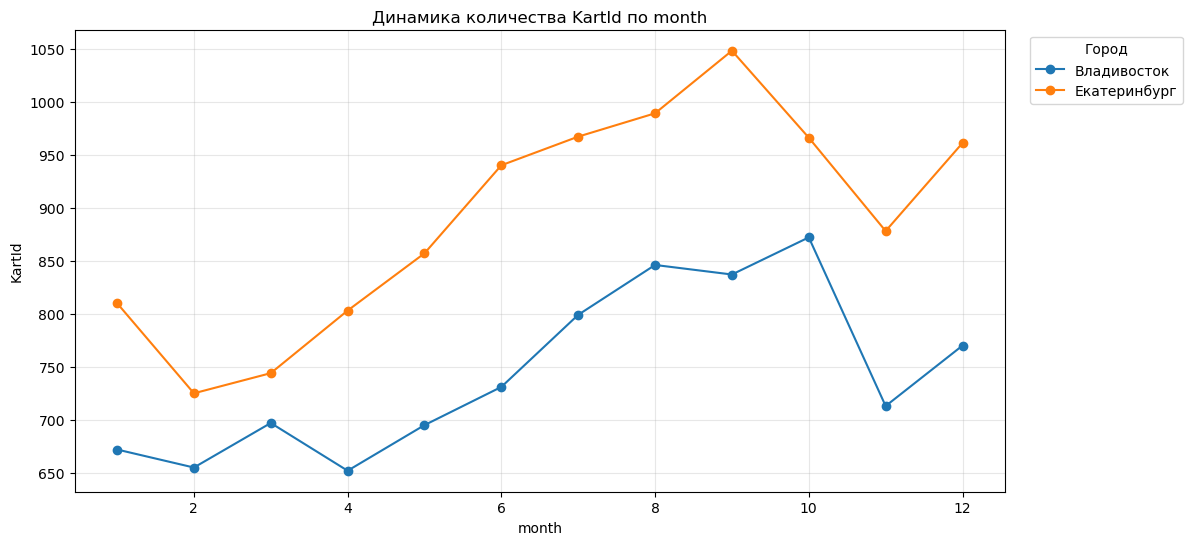

In [12]:
time_line_plot(main_clean, 'KartId', 'month')

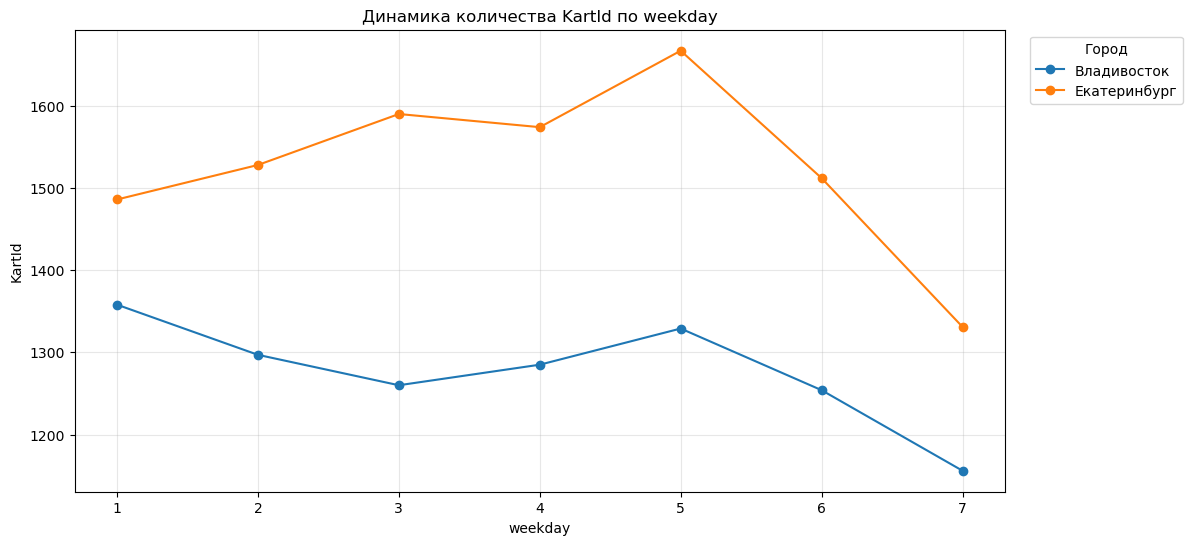

In [13]:
time_line_plot(main_clean, 'KartId', 'weekday')

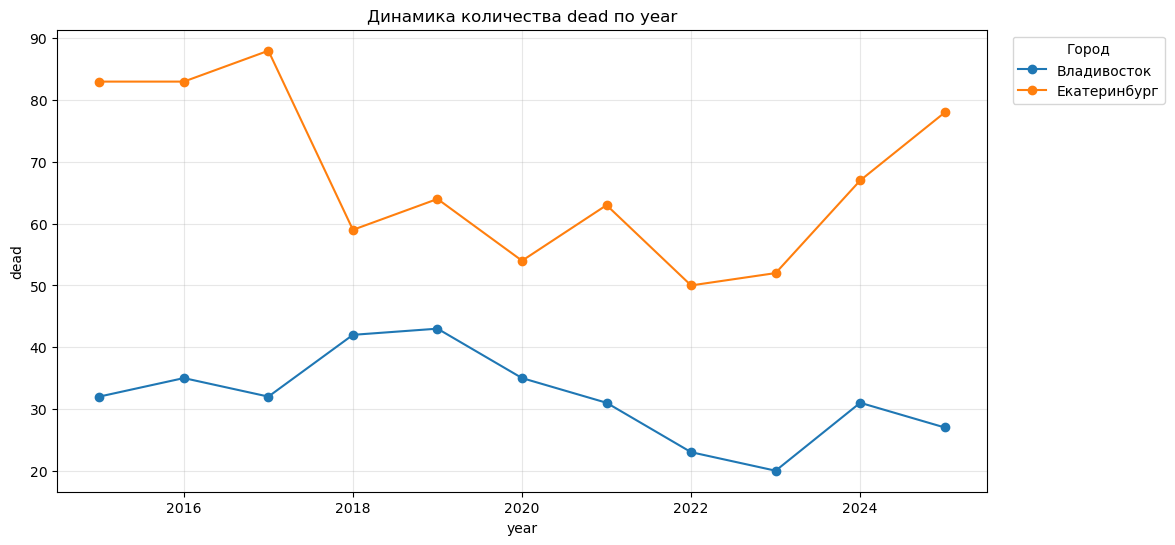

In [14]:
time_line_plot(main_clean, 'dead', 'year')

In [15]:
# данные о численности населения
population = pd.read_csv('wiki_cities.csv')
population_ekb = population.loc[population['city']=='Екатеринбург','population'].values[0]
print(population_ekb)
population_vlad = population.loc[population['city']=='Владивосток','population'].values[0]
print(population_vlad)

1544376
603519


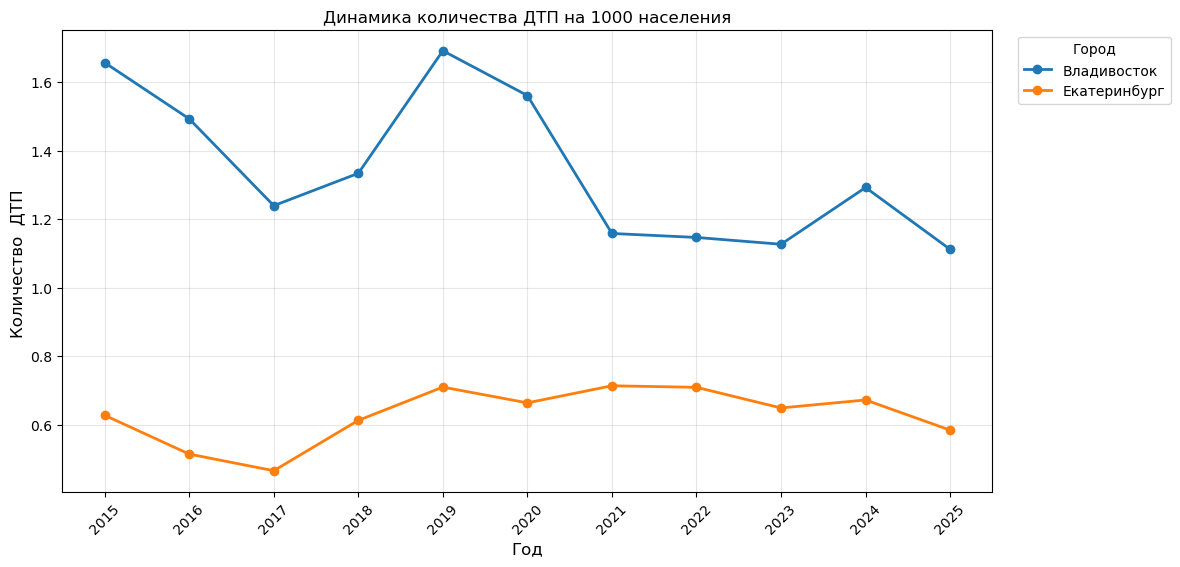

In [16]:
population_dict = {
    'Екатеринбург': population_ekb,
    'Владивосток': population_vlad
}
result = (main_clean.groupby(['city', 'year'])
              .agg(dtp_count=('KartId', 'count'))
              .reset_index())
# Добавляем население и считаем ДТП на 1 000
result['population'] = result['city'].map(population_dict)
result['dtp_per_1k'] = (result['dtp_count'] / result['population']) * 1000

# Создаем сводную таблицу и строим график
pivot_df = result.pivot(index='year', columns='city', values='dtp_per_1k')

# Построение графика одной строкой
ax = pivot_df.plot(kind='line', 
                   figsize=(12, 6), 
                   marker='o', 
                   linewidth=2, 
                   markersize=6,
                   title='Динамика количества ДТП на 1000 населения')

# Настройка внешнего вида
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Количество  ДТП ', fontsize=12)
ax.legend(title='Город', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
ax.set_xticks(pivot_df.index)
ax.set_xticklabels(pivot_df.index, rotation=45)
plt.show()



In [17]:
def value_counts_plot(df: pd.DataFrame, column: str, cities: list):
    ''' 
    Строит барплот ТОП-10 значений выбранного признака 
    по количеству ДТП для нескольких городов на одном графике
    '''
    # Фильтруем данные по городам
    df_filtered = df[df['city'].isin(cities)]
    
    # Получаем ТОП-10 значений признака (суммарно по всем городам)
    top_10 = (df_filtered.groupby(column)
              .size()
              .sort_values(ascending=False)
              .head(10))
    
    top_values = top_10.index  # Извлекаем названия категорий в порядке убывания
    
    # Создаем сводную таблицу
    pivot_df = (df_filtered[df_filtered[column].isin(top_values)]
                .groupby([column, 'city'])
                .size()
                .unstack(fill_value=0))
    
    # Сортируем строки сводной таблицы по общему количеству ДТП (сумма по городам)
    pivot_df['total'] = pivot_df.sum(axis=1)  # Добавляем временный столбец с суммой
    pivot_df = pivot_df.sort_values('total', ascending=False)  # Сортируем по убыванию
    pivot_df = pivot_df.drop('total', axis=1)  # Удаляем временный столбец
    
    # Рисуем grouped bar chart
    pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    
    plt.title(f'ТОП-10 по {column} в 2015-2025', fontsize=12)
    plt.xlabel(column, fontsize=10)
    plt.ylabel('Количество ДТП', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Город', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [18]:
def dead_counts_plot(df: pd.DataFrame, column: str, cities: list):
    ''' 
    Строит барплот ТОП-10 значений выбранного признака 
    по сумме погибших в ДТП для нескольких городов на одном графике
    '''
    # Фильтруем данные по городам
    df_filtered = df[df['city'].isin(cities)]
    
    # Получаем ТОП-10 значений признака (суммарно по всем городам)
    top_10 = (df_filtered.groupby(column)['dead'].sum()
              .sort_values(ascending=False)
              .head(10))
    
    top_values = top_10.index 
    
  
    pivot_df = (df_filtered[df_filtered[column].isin(top_values)]
                .groupby([column, 'city'])['dead'] 
                .sum()  
                .unstack(fill_value=0))
    
    # Сортируем строки сводной таблицы по общему количеству погибших (сумма по городам)
    pivot_df['total'] = pivot_df.sum(axis=1) 
    pivot_df = pivot_df.sort_values('total', ascending=False)  
    pivot_df = pivot_df.drop('total', axis=1)  
    
    # Рисуем grouped bar chart
    pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    
    plt.title(f'ТОП-10 по {column} в 2015-2025', fontsize=12)
    plt.xlabel(column, fontsize=10)
    plt.ylabel('Количество погибших', fontsize=10)  
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Город', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

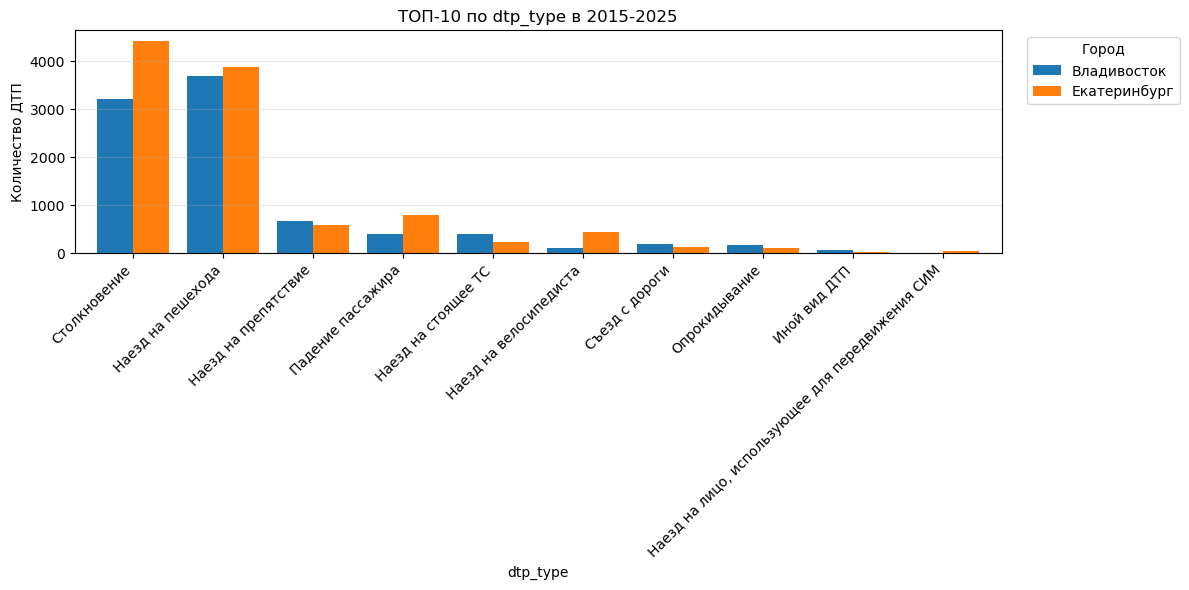

In [19]:
value_counts_plot(main_clean, 'dtp_type', ['Екатеринбург', 'Владивосток'])

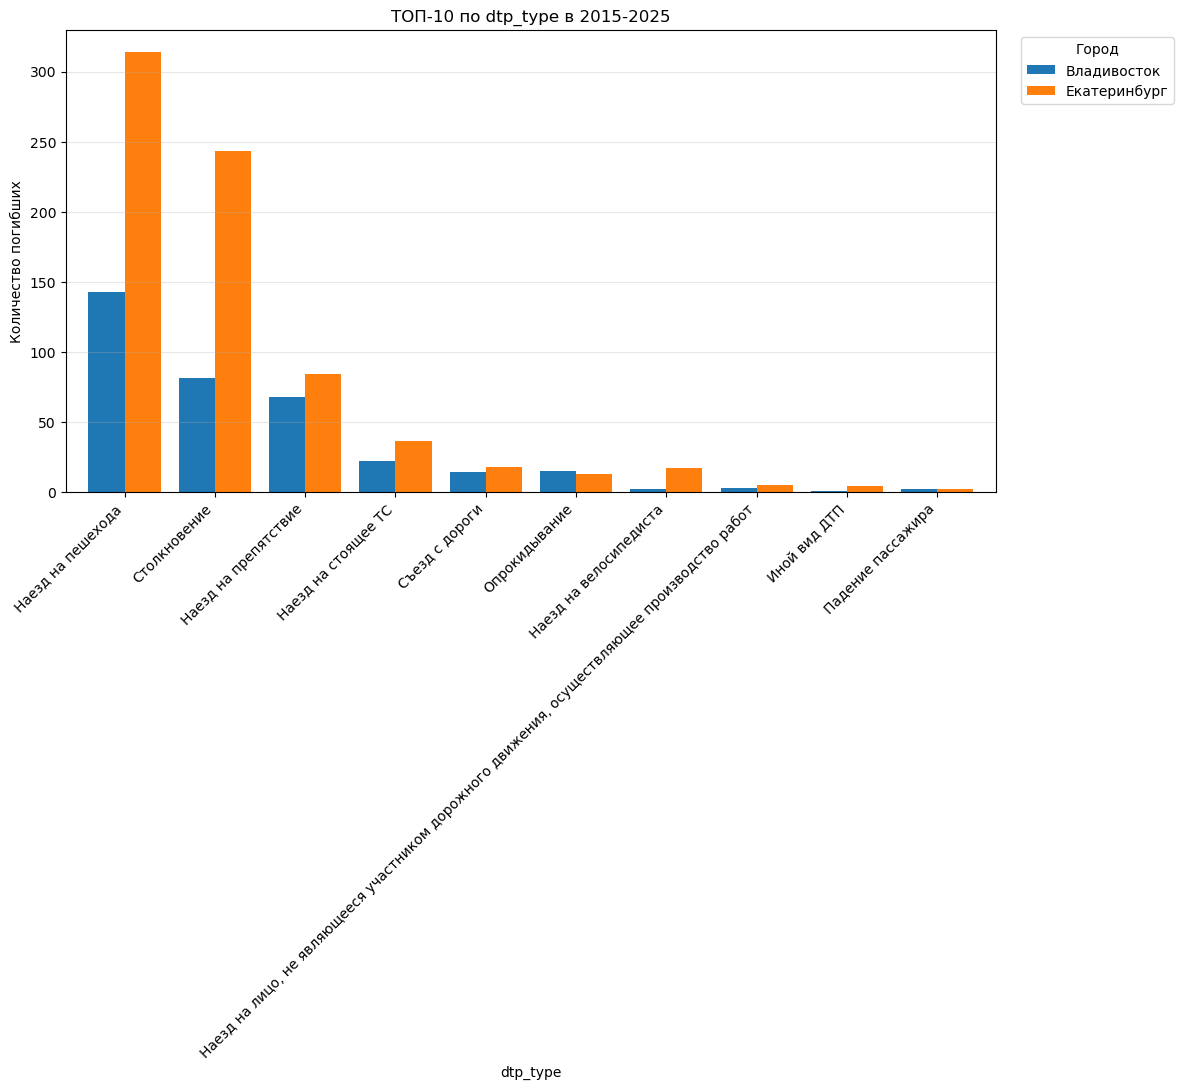

In [20]:
dead_counts_plot(main_clean, 'dtp_type', ['Екатеринбург', 'Владивосток'])

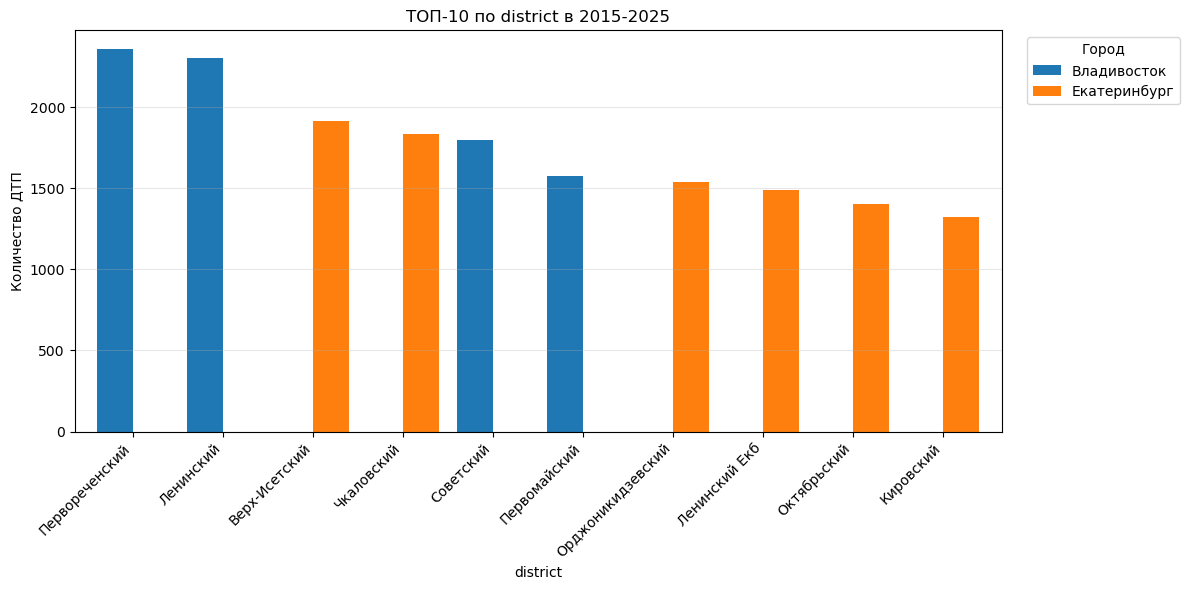

In [21]:
value_counts_plot(main_clean, 'district', ['Екатеринбург', 'Владивосток'])

**Выводы**
- в обоих городах наблюдается снижение количества ДТП после пика 2019 года, но во Владивостоке оно более существенное
- однако количество погибших в ДТП в Екатеринбурге растет с 2019г, в отличие от Владивостока, где стабильное снижение (с 2019), за исключением одного года (2024), когда наблюдался небольшой прирост
- тем не менее дтп на 1000 населения в Екатеринбурге остается ниже (в среднем 0,6 и почти без изменений на всем периоде), чем во Владивостоке (более 1 на всем периоде), хотя во Владивостоке также наблюдается снижение этого показателя. 
- самые популярные виды ДТП  - это столкновение и наезд на пешехода в обоих городах
- в обоих городах месячная динамика схожа: зимние месяцы спад, постепенный рост весной и летом. в Екатеринбурге пик - сентябрь, во Владивостоке - октябрь, далее резкий спад в ноябре. Вероятные причины роста ДТП летом: рост трафика на трассах (поездки в отпуск, на дачу и т.д.), появление новых участников движения (велосипеды, самокаты), рост числа пешеходов. 
- динамика по дням недели также схожа: пик количества ДТП - в пятницу, снижение в выходные (т.к. в выходные стабильно меньше трафик, чем в будние дни)

### 2. Статистика по участникам ДТП и транспортным средствам

In [22]:
try:
    query_uch = '''
           SELECT *
           FROM uch_clean;
          '''
    uch_clean = pd.read_sql_query(query_uch, con=engine)

except: 
    uch_clean = pd.read_csv('uch_clean.csv')

In [23]:
uch_clean.info()
uch_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40748 entries, 0 to 40747
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   KartId         40748 non-null  int64  
 1   category_part  40748 non-null  object 
 2   injury_type    40522 non-null  object 
 3   pol            40630 non-null  object 
 4   years_driving  30132 non-null  float64
 5   alcohol        11354 non-null  float64
 6   safety_belt    40748 non-null  object 
 7   S_SM           40748 non-null  object 
 8   NPDD           40748 non-null  object 
 9   SOP_NPDD       40748 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 3.1+ MB


,KartId,category_part,injury_type,pol,years_driving,alcohol,safety_belt,S_SM,NPDD,SOP_NPDD
0,161237026,Водитель,Не пострадал,Мужской,17.0,NaN,Да,Нет (не скрывался),Несоответствие скорости конкретным условиям дв...,Нет нарушений
1,161237026,Водитель,"Раненый, находящийся (находившийся) на стацион...",Женский,7.0,NaN,Да,Нет (не скрывался),Нет нарушений,Нет нарушений
2,161340310,Водитель,Не пострадал,Мужской,10.0,NaN,Да,"Скрылся, впоследствии разыскан (установлен)","Несоблюдение условий, разрешающих движение тра...",Оставление места ДТП
3,161238027,Водитель,"Раненый, находящийся (находившийся) на стацион...",Женский,2.0,15.0,Да,Нет (не скрывался),Другие нарушения ПДД водителем,Управление ТС в состоянии алкогольного опьянения
4,171517613,Водитель,Не пострадал,Мужской,2.0,NaN,Да,Нет (не скрывался),Нет нарушений,Нет нарушений


In [24]:
try:
    query_ts = '''
           SELECT *
           FROM uch_clean;
          '''
    ts_clean = pd.read_sql_query(query_ts, con=engine)

except: 
    ts_clean = pd.read_csv('ts_clean.csv')

In [25]:
ts_clean.info()
ts_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32517 entries, 0 to 32516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   KartId             32517 non-null  int64  
 1   number_ts          32517 non-null  int64  
 2   type_ts            32316 non-null  object 
 3   marka_ts           30251 non-null  object 
 4   model_ts           30251 non-null  object 
 5   year_release       30431 non-null  float64
 6   damage             6229 non-null   object 
 7   technical_defects  32517 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 2.0+ MB


,KartId,number_ts,type_ts,marka_ts,model_ts,year_release,damage,technical_defects
0,161237026,1,"D-класс (средний) до 4,6 м",ВАЗ,Прочие модели ВАЗ,2013.0,Передний правый угол | Передний левый угол,Технические неисправности отсутствуют
1,161237026,2,"D-класс (средний) до 4,6 м",OPEL,Meriva,2007.0,Задний правый угол | Задний левый угол,Технические неисправности отсутствуют
2,161340310,1,"D-класс (средний) до 4,6 м",FORD,Focus,2007.0,NaN,Технические неисправности отсутствуют
3,161238027,1,Минивэны и универсалы повышенной вместимости,MAZDA,CX-7,2010.0,Крыша | Полная деформация кузова | Смещение дв...,Технические неисправности отсутствуют
4,171517613,1,"С-класс (малый средний, компактный) до 4,3 м",ВАЗ,Kalina,2008.0,Передний правый угол,Технические неисправности отсутствуют


In [26]:
# присоединим название города в таблицы для дальнейшего анализа в разбивке по городам
ts_clean = ts_clean.merge(main_clean[['KartId', 'city']], on = 'KartId', how = 'left')
uch_clean = uch_clean.merge(main_clean[['KartId', 'city']], on = 'KartId', how = 'left')

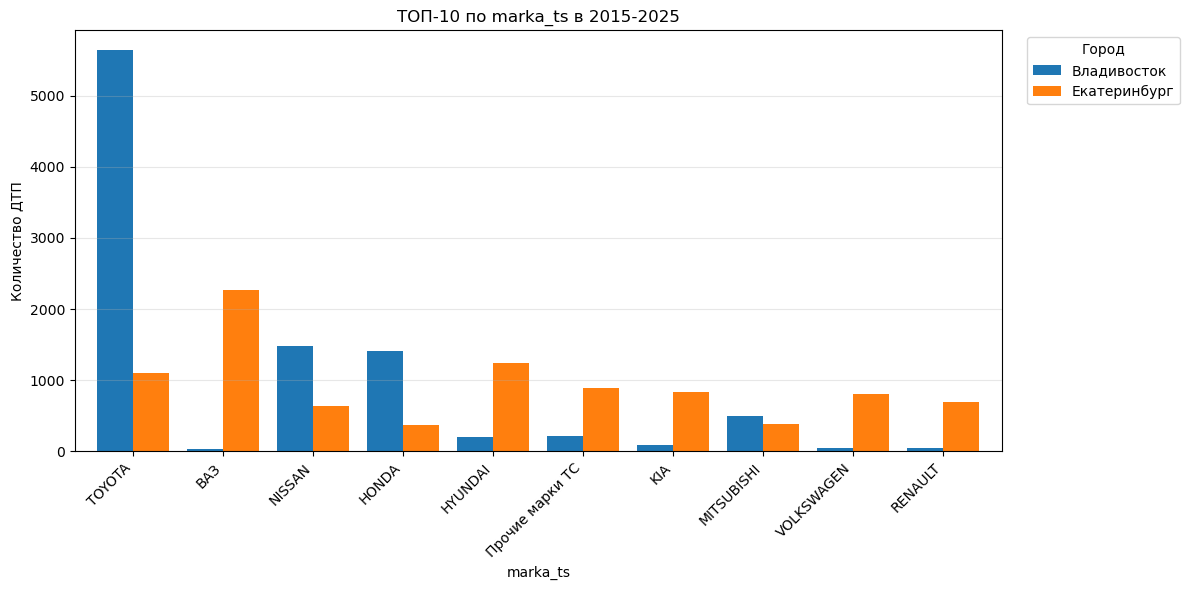

In [27]:
value_counts_plot(ts_clean, 'marka_ts', ['Екатеринбург', 'Владивосток'])

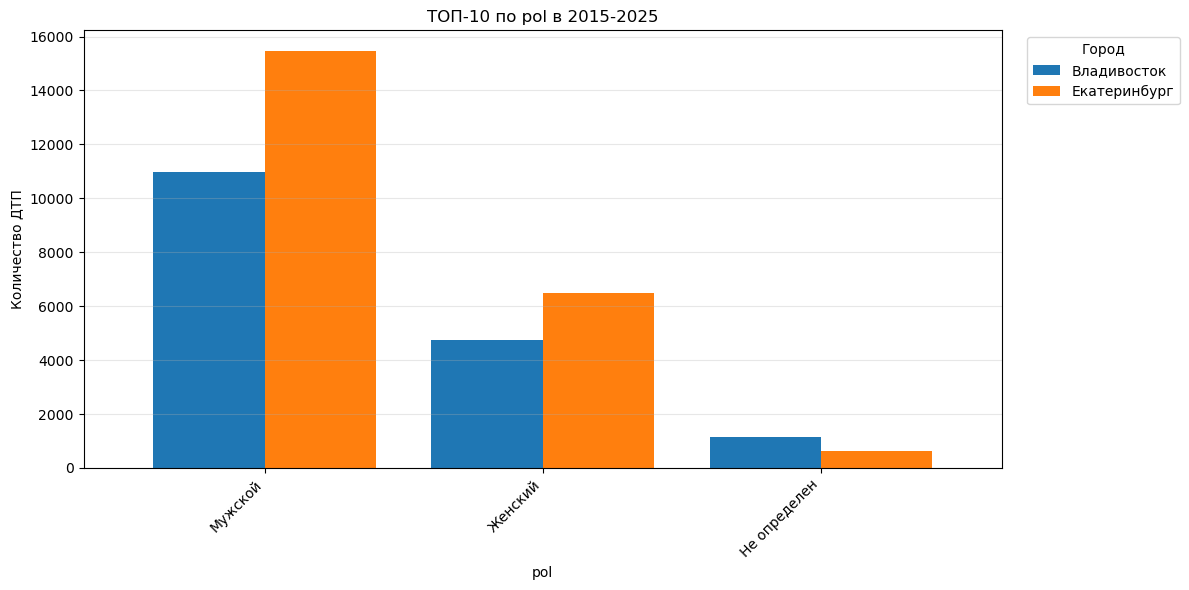

In [28]:
value_counts_plot(uch_clean, 'pol', ['Екатеринбург', 'Владивосток'])

**Распределение водительского стажа**

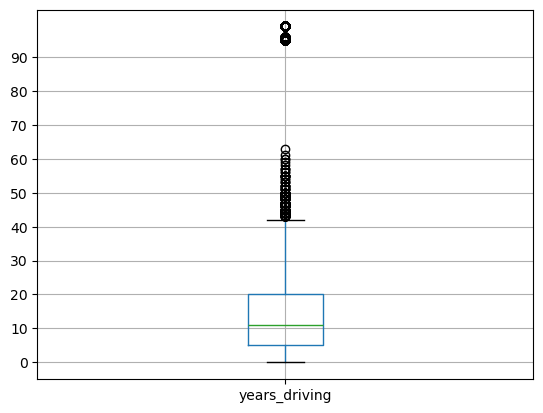

In [29]:
uch_clean[['years_driving']].boxplot()
plt.yticks(range(0,100,10))
plt.show()

**Вывод**: медианный стаж вождения водителей-участников ДТП = 10 лет, 25% водителей со стажем до 5 лет, 75% водителей со стажем до 20 лет. При 
этом есть аномальные значения стажа вождения - более 90 лет (выбросы или ошибки в данных).

**Выделим дни с аномальным количеством ДТП**

In [30]:
def extra_DTP_days (city: str):
    '''Сторит боксплот по количеству дтп по выбранному городу '''
    
    df_city = main_clean.loc[main_clean['city']== city]
    day_dtp = df_city.groupby(['date']).agg({
                                     'KartId':'count',
                                     'dead':'sum',
                                      'injured':'sum'
                                     }).reset_index().sort_values(by='KartId', ascending = False)
    day_dtp.rename(columns={'KartId': 'количество_дтп',
                            'dead': 'погибло',
                            'injured': 'ранено'
                           }, inplace=True)

    day_dtp.boxplot()
    plt.title('Распределение показателей ДТП', fontsize=12)
    plt.ylabel('Количество', fontsize=12)
    ymin, ymax = plt.ylim()
    plt.yticks(np.arange(int(ymin), int(ymax) + 1, 2))
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

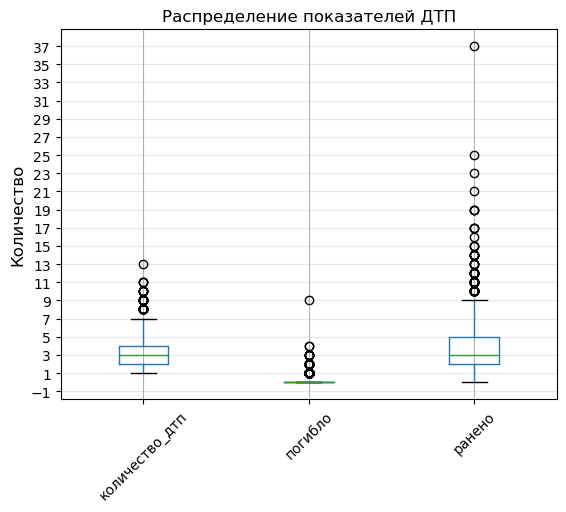

In [31]:
extra_DTP_days('Екатеринбург')

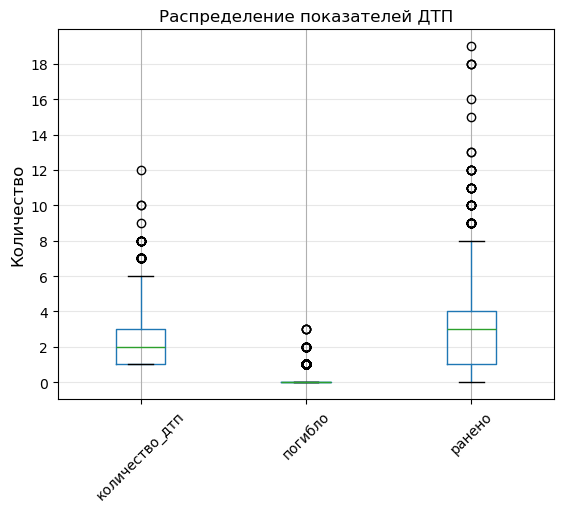

In [32]:
extra_DTP_days('Владивосток')

Вывод: показатели во Владивостоке немного лучше, чем в Екб. В Екб медианное значение количества ДТП = 3, во Владивостоке -2. Для Екб количество ДТП в день больше 7 является аномальным, для Владивостока - больше 6 

### 3. Влияние погоды на ДТП

In [33]:
# добавим данные с количеством погибших 
info_dtp_clean_dead = info_dtp_clean.merge(main_clean[['dead','KartId']], on = 'KartId', how='left')

**Проверим количество ДТП в зависимости от погодных условий** 

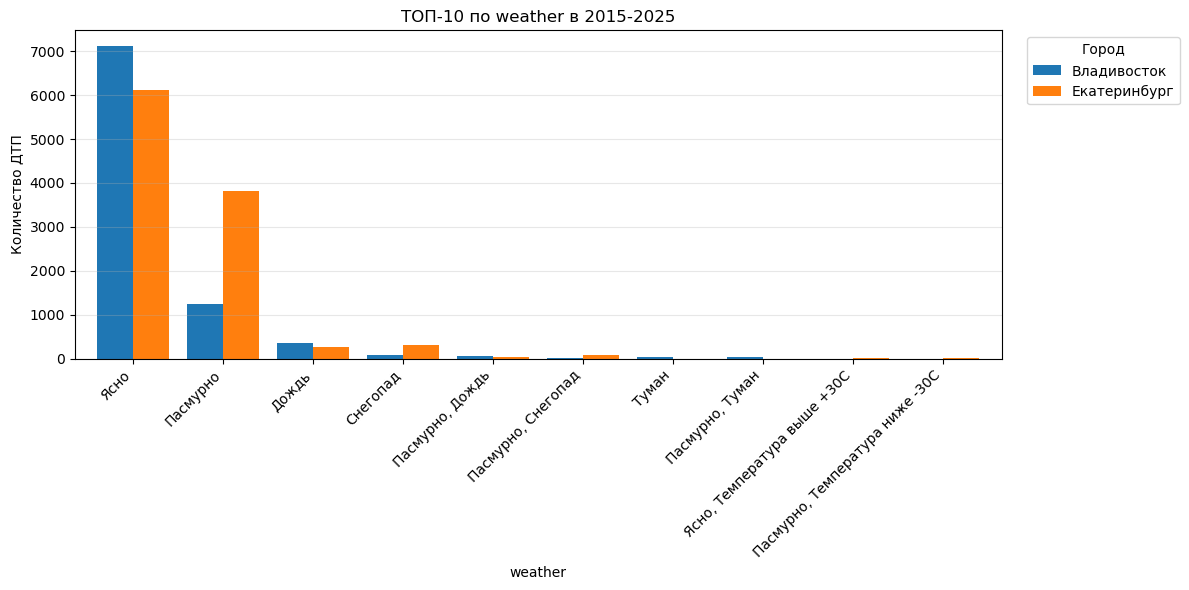

In [34]:
value_counts_plot(info_dtp_clean, 'weather', ['Екатеринбург', 'Владивосток'])

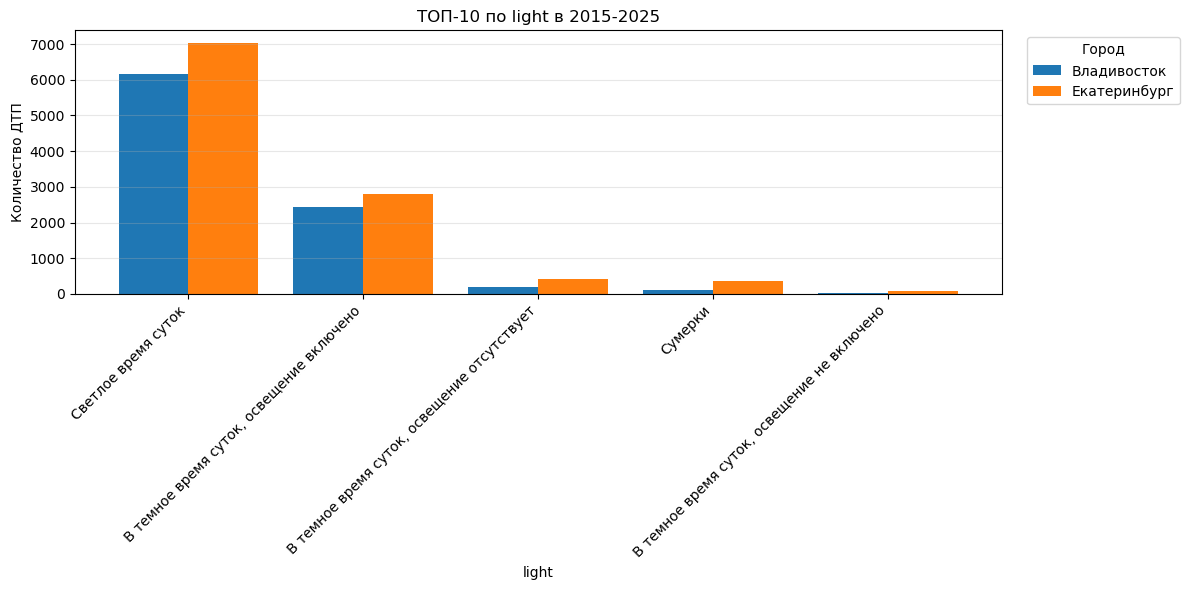

In [35]:
value_counts_plot(info_dtp_clean, 'light', ['Екатеринбург', 'Владивосток'])

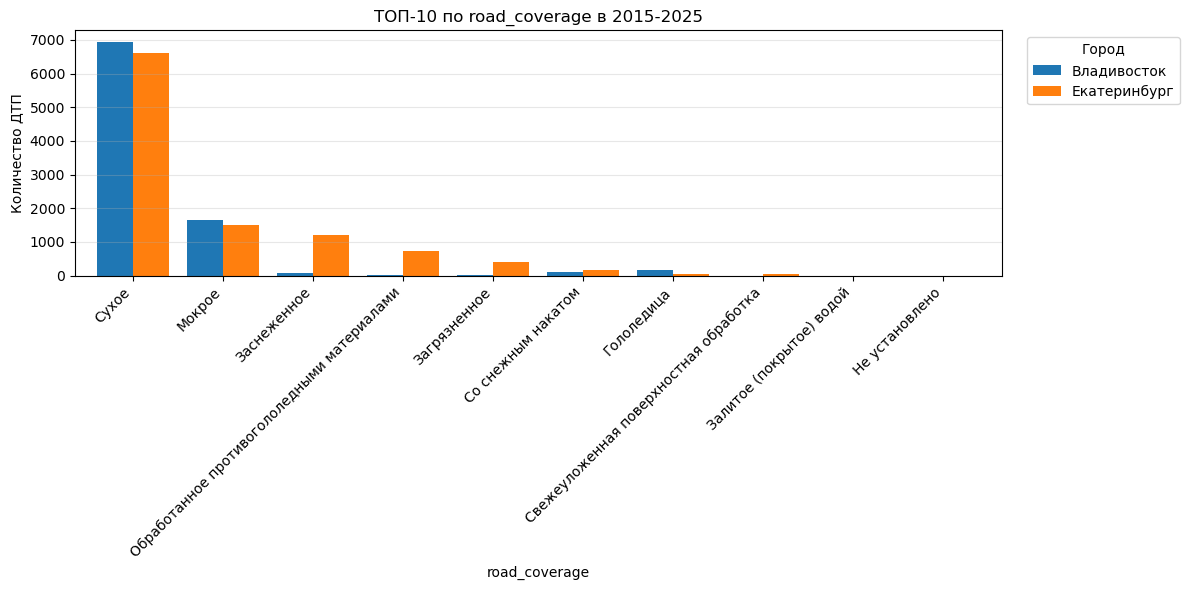

In [36]:
value_counts_plot(info_dtp_clean, 'road_coverage', ['Екатеринбург', 'Владивосток'])

**Вывод:** большая часть ДТП совершена при сухой и ясной погоде в обоих городах.  Однако делать вывод о невлиянии погодных условий на количество ДТП в данном случае некорректно. В данных информация только о днях, когда было хоть одно ДТП. Кроме того в данных нет информации о количестве выезжающих на дороги машин в целом (т.е. в плохую погоду меньше трафик, следовательно и ДТП меньше, однако в % отношении общего числа машин на дорогах, эта статистика может быть другой).

**Проверим количество погибших в ДТП в зависимости от погодных условий** 

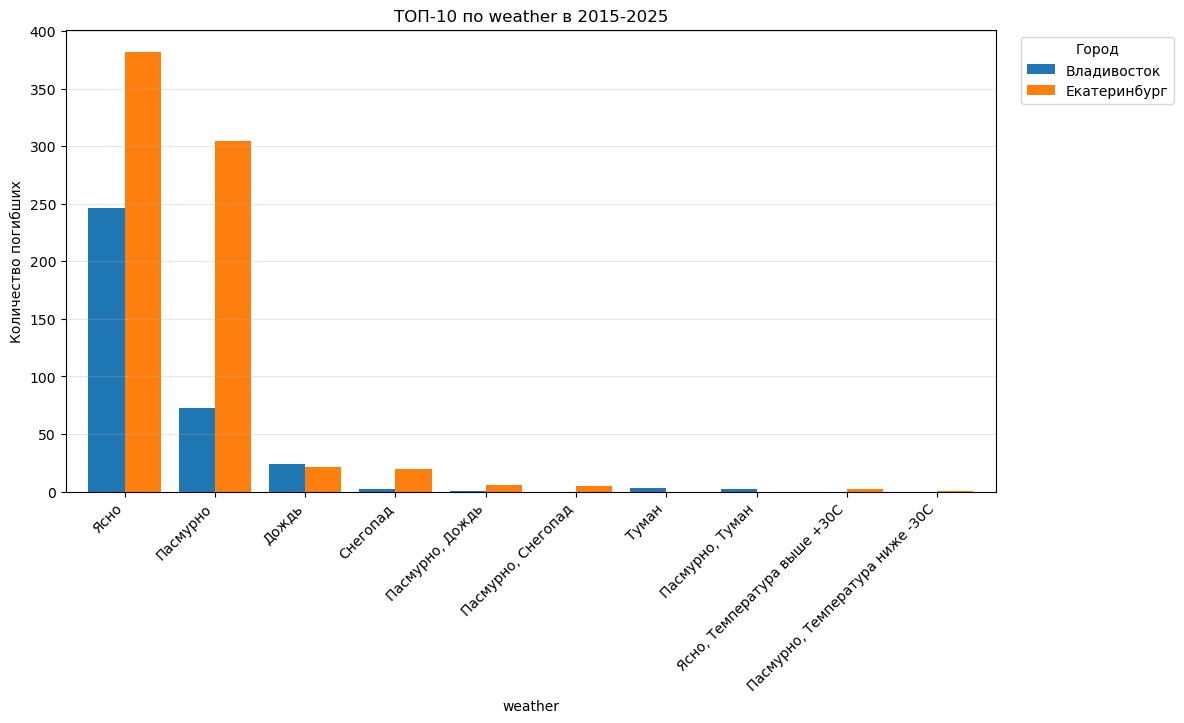

In [37]:
dead_counts_plot(info_dtp_clean_dead, 'weather', ['Екатеринбург', 'Владивосток'])

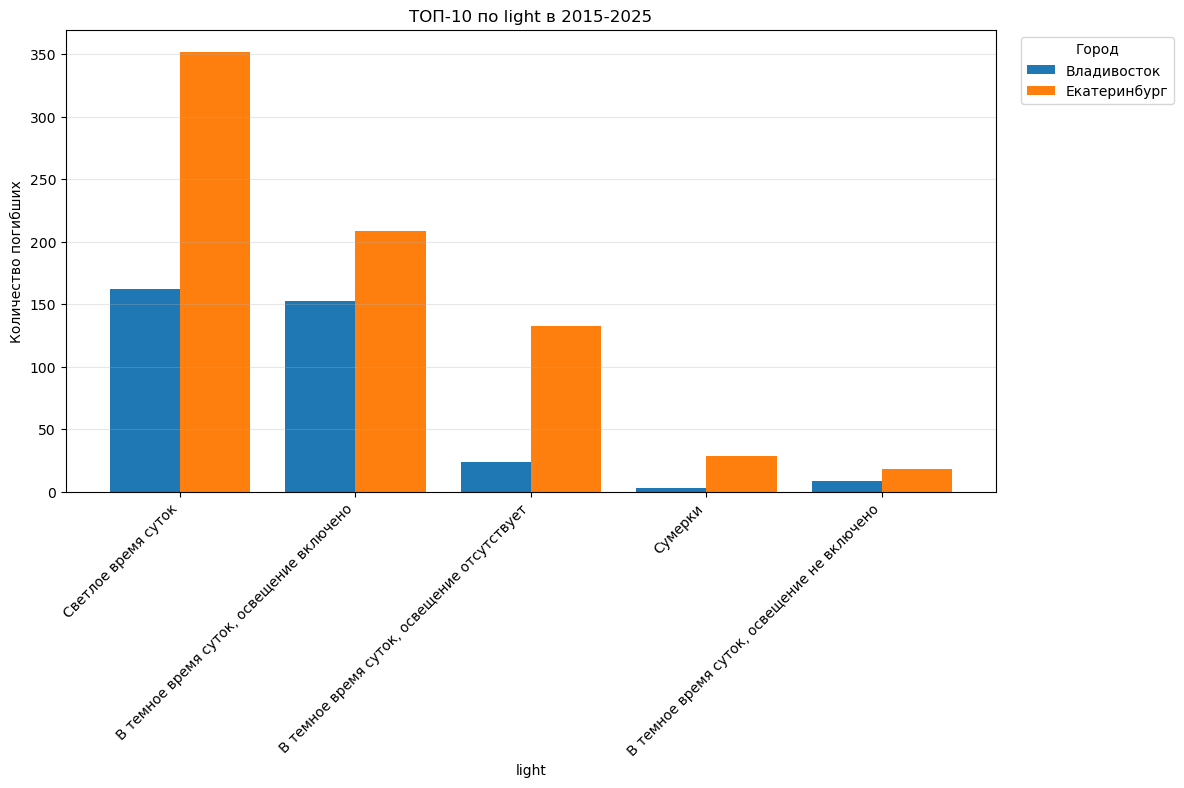

In [38]:
dead_counts_plot(info_dtp_clean_dead, 'light', ['Екатеринбург', 'Владивосток'])

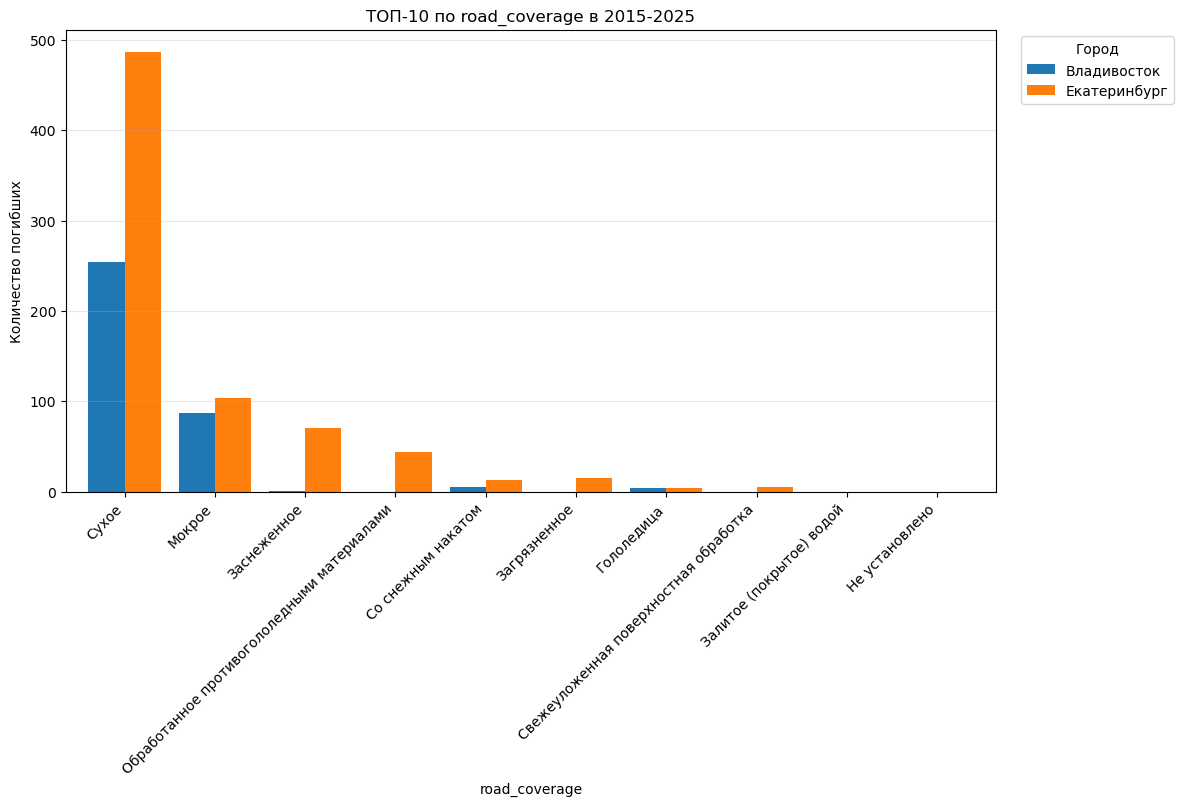

In [39]:
dead_counts_plot(info_dtp_clean_dead, 'road_coverage', ['Екатеринбург', 'Владивосток'])

**Вывод** количество погибших также как и  количество ДТП, наибольшее число в ясную и сухую погоду в светлое время суток в обоих городах. 

**Выгрузим данные о погоде**

In [40]:
# выгрузим данные о погоде
try:
    query_meteo_Ekb = '''
        SELECT *
        FROM "meteo_Ekb_clean"
        '''
    meteo_ekb = pd.read_sql_query(query_meteo_Ekb, con=engine)
except: 
    meteo_ekb = pd.read_csv('meteo_Ekb_clean.csv')


In [41]:
# выгрузим данные о погоде
try:
    query_meteo_Vlad = '''
        SELECT *
        FROM "meteo_Vlad_clean"
        '''
    meteo_vlad = pd.read_sql_query(query_meteo_Vlad, con=engine)
except: 
    meteo_vlad = pd.read_csv('meteo_Vlad_clean.csv')

In [42]:
meteo_ekb.info()
meteo_ekb['date'] = pd.to_datetime(meteo_ekb['date'])
meteo_ekb.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               4019 non-null   object 
 1   date               4019 non-null   object 
 2   temp_mean          4019 non-null   float64
 3   temp_min           4019 non-null   float64
 4   temp_max           4019 non-null   float64
 5   wind_max           4019 non-null   float64
 6   precipitation_sum  4019 non-null   float64
 7   rain_sum           4019 non-null   float64
 8   snowfall_sum       4019 non-null   float64
 9   year               4019 non-null   int64  
 10  month              4019 non-null   int64  
 11  day                4019 non-null   int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 376.9+ KB


,city,date,temp_mean,temp_min,temp_max,wind_max,precipitation_sum,rain_sum,snowfall_sum,year,month,day
0,Екатеринбург,2015-01-01,-23.4,-27.7,-20.0,11.5,0.0,0.0,0.00,2015,1,1
1,Екатеринбург,2015-01-02,-27.5,-29.7,-24.2,9.2,0.0,0.0,0.00,2015,1,2
2,Екатеринбург,2015-01-03,-21.3,-29.8,-10.0,18.4,0.9,0.0,1.05,2015,1,3
3,Екатеринбург,2015-01-04,-4.5,-8.1,-3.0,19.1,1.0,0.0,0.77,2015,1,4
4,Екатеринбург,2015-01-05,-4.0,-6.4,-2.0,18.7,0.0,0.0,0.00,2015,1,5


In [43]:
meteo_vlad.info()
meteo_vlad['date'] = pd.to_datetime(meteo_vlad['date'])
meteo_vlad.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               4019 non-null   object 
 1   date               4019 non-null   object 
 2   temp_mean          4019 non-null   float64
 3   temp_min           4019 non-null   float64
 4   temp_max           4019 non-null   float64
 5   wind_max           4019 non-null   float64
 6   precipitation_sum  4019 non-null   float64
 7   rain_sum           4019 non-null   float64
 8   snowfall_sum       4019 non-null   float64
 9   year               4019 non-null   int64  
 10  month              4019 non-null   int64  
 11  day                4019 non-null   int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 376.9+ KB


,city,date,temp_mean,temp_min,temp_max,wind_max,precipitation_sum,rain_sum,snowfall_sum,year,month,day
0,Владивосток,2015-01-01,-10.7,-12.3,-9.0,30.7,0.0,0.0,0.00,2015,1,1
1,Владивосток,2015-01-02,-10.7,-12.8,-7.6,22.4,0.0,0.0,0.00,2015,1,2
2,Владивосток,2015-01-03,-8.3,-11.0,-3.8,18.3,0.0,0.0,0.00,2015,1,3
3,Владивосток,2015-01-04,-4.9,-9.7,-2.1,10.9,0.0,0.0,0.00,2015,1,4
4,Владивосток,2015-01-05,-2.8,-10.0,0.9,21.2,1.7,1.0,0.49,2015,1,5


In [44]:
# подготовим инфо по Екб
info_ekb = main_clean.loc[(main_clean['city']=='Екатеринбург')].groupby(['date']).agg({'KartId':'count',
                                                                                    'dead':'sum',
                                                                                    'injured':'sum'}).reset_index()

info_ekb = info_ekb.rename(columns={'KartId':'DTP_count'})
                                   
# присоединим данные о погоде
info_ekb = info_ekb.merge(meteo_ekb, on='date', how ='left')


In [45]:
# подготовим инфо по Владивостоку
info_vlad = main_clean.loc[(main_clean['city']=='Владивосток')].groupby(['date']).agg({'KartId':'count',
                                                                                    'dead':'sum',
                                                                                    'injured':'sum'}).reset_index()

info_vlad = info_vlad.rename(columns={'KartId':'DTP_count'})
                                   
# присоединим данные о погоде
info_vlad = info_vlad.merge(meteo_vlad, on='date', how ='left')



**Екатеринбург**

In [46]:
# посмотрим распределение осадков и ДТП
def get_hist(df: pd.DataFrame, column: str):
    '''
    Строит гистограммы для выбранного признака
    '''
    df[column].hist(
        bins=10,
        figsize=(8, 4),
        color='skyblue',
        edgecolor='black',
        
    )
   
    plt.suptitle(f'Гистограмма {column}', fontsize=10)
    plt.xlabel(column, fontsize=8)
    plt.ylabel('Количество дней', fontsize=10)
    plt.show()

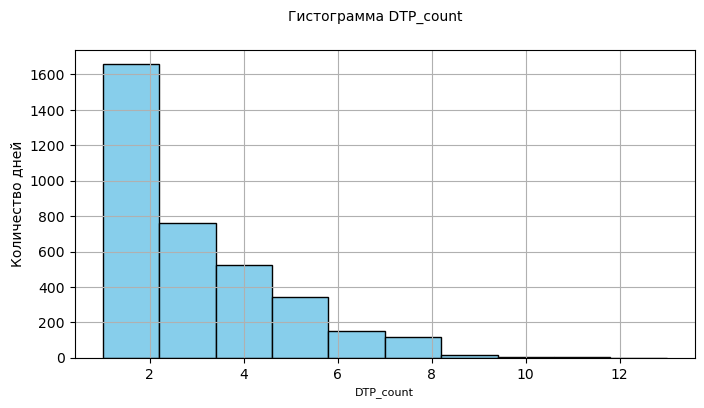

In [47]:
get_hist(info_ekb, 'DTP_count')

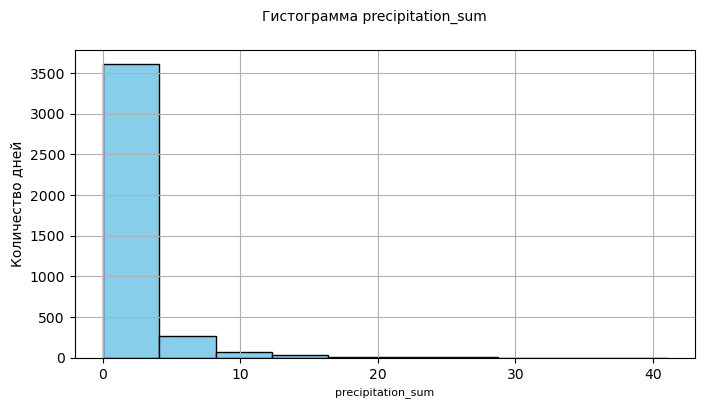

In [48]:
get_hist(meteo_ekb, 'precipitation_sum')

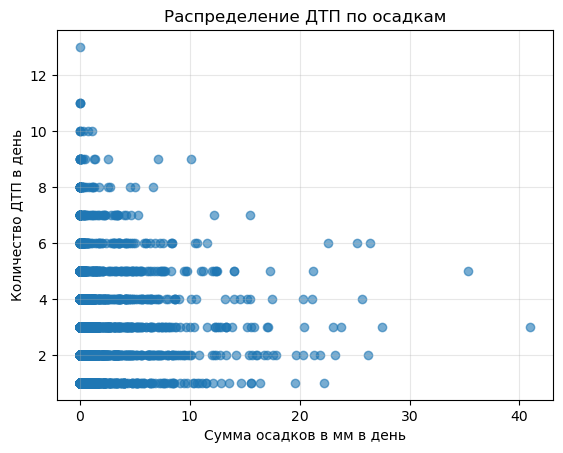

In [49]:
# построим даиграмму рассеяния
plt.scatter(info_ekb['precipitation_sum'], info_ekb['DTP_count'], alpha=0.6)
plt.title('Распределение ДТП по осадкам')
plt.ylabel('Количество ДТП в день')
plt.xlabel('Сумма осадков в мм в день')
plt.grid(True, alpha=0.3)
plt.show()

**Вывод:** диаграмма подтверждает, что большая часть дтп происходит в сухую погоду, т.к. именно сухая погода более типична для региона.

In [50]:
pearson_corr = stats.pearsonr(info_ekb['precipitation_sum'], info_ekb['DTP_count'])
spearman_corr = stats.spearmanr(info_ekb['precipitation_sum'], info_ekb['DTP_count'])
print(f"\nКорреляция Пирсона: {pearson_corr[0]:.2f}")
print(f"Корреляция Спирмана: {spearman_corr[0]:.2f}")


Корреляция Пирсона: 0.03
Корреляция Спирмана: 0.04


**Вывод:** низкое значение корреляции показывает отсутствие взаимосвязи

In [51]:
# категорируем данные по осадкам и количеству ДТП
info_ekb['precipitation_group'] = pd.cut(info_ekb['precipitation_sum'],
                               bins=[-1, 0, 10, np.inf],
                               labels=['no_precipitation', 'small_precipitation', 'strong_precipitation'])

ekb_stats = info_ekb.groupby('precipitation_group').agg({'DTP_count':'count',
                                                         'dead': 'sum'
                                                        }).reset_index()

ekb_stats['city']='Екатеринбург'
ekb_stats

C:\Users\Sandy\AppData\Local\Temp\ipykernel_17464\1083045162.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ekb_stats = info_ekb.groupby('precipitation_group').agg({'DTP_count':'count',


,precipitation_group,DTP_count,dead,city
0,no_precipitation,1724,367,Екатеринбург
1,small_precipitation,1769,347,Екатеринбург
2,strong_precipitation,91,27,Екатеринбург


**Вывод**: 
 - при сильных осадках в абсолютном выражении количество ДТП и число погибших резко снижается , однако в относительном выражении доля погибших (почти 30% от количества ДТП) становится выше, чем при сухой погоде (21%) или незначительных осадках (20%).  

**Владивосток**

Проведем аналогичные расчеты 

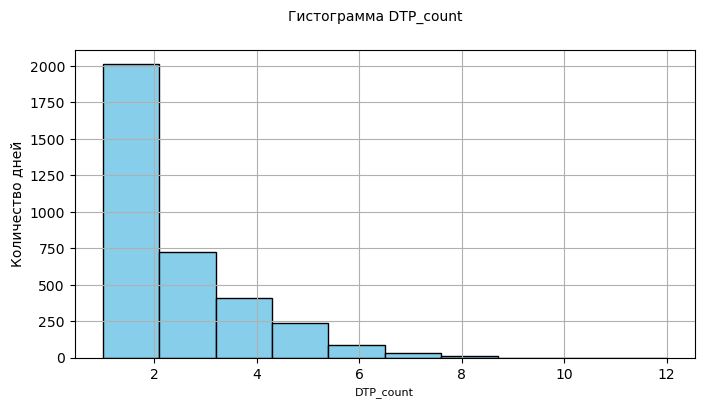

In [52]:
get_hist(info_vlad, 'DTP_count')

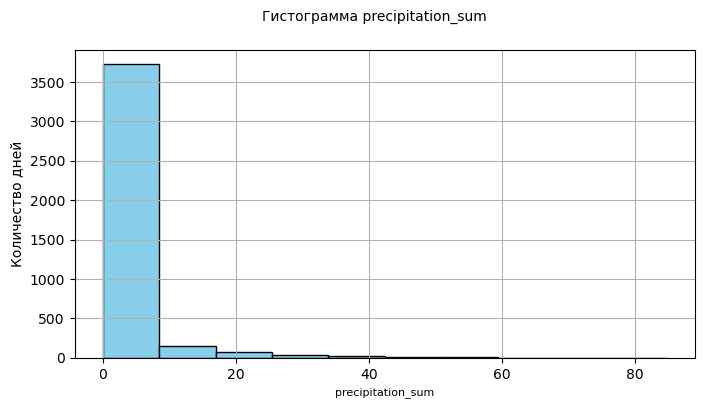

In [53]:
get_hist(meteo_vlad, 'precipitation_sum')

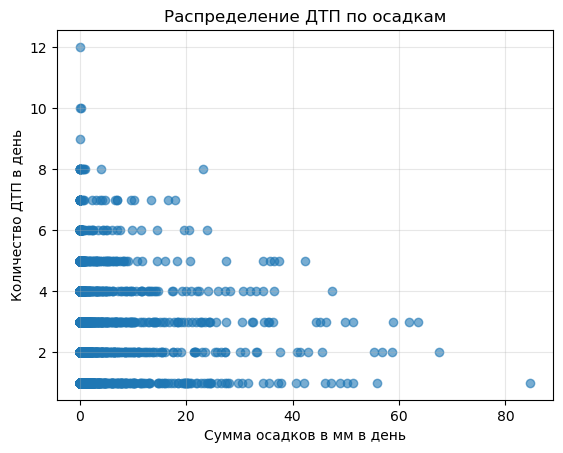

In [54]:
plt.scatter(info_vlad['precipitation_sum'], info_vlad['DTP_count'], alpha=0.6)
plt.title('Распределение ДТП по осадкам')
plt.ylabel('Количество ДТП в день')
plt.xlabel('Сумма осадков в мм в день')
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# категорируем данные по осадкам и количеству ДТП
info_vlad['precipitation_group'] = pd.cut(info_vlad['precipitation_sum'],
                               bins=[-1, 0, 10, np.inf],
                               labels=['no_precipitation', 'small_precipitation', 'strong_precipitation'])

vlad_stats = info_vlad.groupby('precipitation_group').agg({'DTP_count':'count',
                                                         'dead': 'sum'
                                                        }).reset_index()

vlad_stats['city']='Владивосток'
vlad_stats

C:\Users\Sandy\AppData\Local\Temp\ipykernel_17464\3400378022.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vlad_stats = info_vlad.groupby('precipitation_group').agg({'DTP_count':'count',


,precipitation_group,DTP_count,dead,city
0,no_precipitation,2020,189,Владивосток
1,small_precipitation,1280,143,Владивосток
2,strong_precipitation,223,19,Владивосток


**Вывод** количество ДТП при сильных осадках резко снижается (что скорее всего, обусловлено снижением трафика в плохую погоду), при этом смертность также снижается (8%) относительно (9%) при сухой погоде.  

### 3. Категоризация данных


**Категорируем некоторые данные по участникам для дальнейшего анализа и проверки гипотез**

In [56]:
# удаляем пропуски 
uch_clean2 = uch_clean.dropna(subset =['safety_belt','injury_type', 'alcohol']).copy()
uch_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11354 entries, 3 to 40747
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   KartId         11354 non-null  int64  
 1   category_part  11354 non-null  object 
 2   injury_type    11354 non-null  object 
 3   pol            11354 non-null  object 
 4   years_driving  8664 non-null   float64
 5   alcohol        11354 non-null  float64
 6   safety_belt    11354 non-null  object 
 7   S_SM           11354 non-null  object 
 8   NPDD           11354 non-null  object 
 9   SOP_NPDD       11354 non-null  object 
 10  city           10981 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.0+ MB


In [57]:
#  категоризация данных 
def set_belt_category(value):
    if value == 'Нет':
        return 0
    else:
        return 1

In [58]:
uch_clean2['safety_belt_group'] = uch_clean2['safety_belt'].apply(set_belt_category)

In [59]:
def set_injury_category(value):
    if isinstance(value, str) and "Скончался" in value:
        return 2
    elif value == 'Не пострадал':
        return 0
    else:
        return 1

In [63]:
uch_clean2['injury_type_group'] = uch_clean2['injury_type'].apply(set_injury_category)

In [60]:
def set_alcohol_category(value):
    if (value <= 3.  # допустимая норма для водителей в РФ
        ):
        return 0
    else:
        return 1

In [61]:
uch_clean2['alcohol_group'] = uch_clean2['alcohol'].apply(set_alcohol_category)

In [64]:
# создадим отдельный датафрейм с категориями
uch_corr = uch_clean2.loc[:,['injury_type_group','safety_belt_group', 'alcohol_group']].copy()

uch_corr.info()
uch_corr.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 11354 entries, 3 to 40747
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   injury_type_group  11354 non-null  int64
 1   safety_belt_group  11354 non-null  int64
 2   alcohol_group      11354 non-null  int64
dtypes: int64(3)
memory usage: 354.8 KB


,injury_type_group,safety_belt_group,alcohol_group
3,1,1,1
9,0,1,0
27,1,1,0
28,1,1,0
29,1,1,0


In [65]:
# построим матрицу корреляции Пирсона
corr_matrix_Prs = uch_corr.corr()
corr_matrix_Prs

,injury_type_group,safety_belt_group,alcohol_group
injury_type_group,1.000000,-0.249418,0.145174
safety_belt_group,-0.249418,1.000000,-0.165331
alcohol_group,0.145174,-0.165331,1.000000


**Вывод:** данные  показывают  слабую положительную корреляцию между категорией пострадавшего и наличием алкоголя, взаимосвязь с наличием ремня безопасности отрицательная и также слабая (менее 0,5). Слабость взаимосвязи может указывать на нелинейную зависимость, а также на наличие иных факторов, влияющих на показатели.  

### 4. Проверка гипотез

**Гипотеза 1**

HO: Распределение ДТП по типам осадков не зависит от города
(Доля ДТП при сильных/слабых/без осадков одинакова в Екб и Владивостоке)

H1: Распределение ДТП по типам осадков зависит от города
(В одном городе доля ДТП при сильных осадках выше, чем в другом)

Уровень статю значимости 0,05.
Для проверки гипотезы используем хи-квадрат

In [66]:
stats = pd.concat([ekb_stats, vlad_stats], ignore_index=True)
stats

,precipitation_group,DTP_count,dead,city
0,no_precipitation,1724,367,Екатеринбург
1,small_precipitation,1769,347,Екатеринбург
2,strong_precipitation,91,27,Екатеринбург
3,no_precipitation,2020,189,Владивосток
4,small_precipitation,1280,143,Владивосток
5,strong_precipitation,223,19,Владивосток


In [67]:
table_sopr = stats.pivot(index='city', columns='precipitation_group', values='DTP_count')
table_sopr

precipitation_group,no_precipitation,small_precipitation,strong_precipitation
city,,,
Владивосток,2020,1280,223
Екатеринбург,1724,1769,91


In [68]:
ekb_normal = ekb_stats['DTP_count'] / ekb_stats['DTP_count'].sum()
vlad_normal = vlad_stats['DTP_count'] / vlad_stats['DTP_count'].sum()

print("Екатеринбург (доли):")
print(ekb_normal)
print("\nВладивосток (доли):")
print(vlad_normal)

Екатеринбург (доли):
0    0.481027
1    0.493583
2    0.025391
Name: DTP_count, dtype: float64

Владивосток (доли):
0    0.573375
1    0.363327
2    0.063298
Name: DTP_count, dtype: float64


In [69]:
# Тест хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(table_sopr)

print(f"Хи-квадрат = {chi2:.4f}")
print(f"p-value = {p_value:.6f}")


if p_value < 0.05:
    print("Отвергаем H0")
else:
    print(" Не отвергаем H0")

Хи-квадрат = 156.8062
p-value = 0.000000
Отвергаем H0


**Вывод**: 
Распределение ДТП по категориям осадков (без осадков, слабые, сильные) статистически значимо различается между Екатеринбургом и Владивостоком.  Распределение ДТП по типам осадков статистически значимо зависит от города. 

**Гипотеза 2**

Н0: Среднее количество ДТП на 1000 чел. населения в месяц в Екб и Владивостоке одинаковое 

Н1: Среднее количество ДТП на 1000 чел. населения в месяц в Екб и Владивостоке разное

Уровень стат. значимости 0,05. Для проверки гипотезы используем U-критерий Манна-Уитни

In [70]:
# подготовим данные, посчитаем среднемесячные значения
result_month = (main_clean.groupby(['city', 'year','month'])
              .agg(dtp_count=('KartId', 'count'))
              .reset_index())
# Добавляем население и считаем ДТП на 1000
result_month['population'] = result_month['city'].map(population_dict)
result_month['dtp_per_1k'] = (result_month['dtp_count'] / result_month['population']) * 1000

ekb = result_month[result_month['city'] == 'Екатеринбург']['dtp_per_1k'].values
vlad = result_month[result_month['city'] == 'Владивосток']['dtp_per_1k'].values

print(f"Размер выборок: Екб={len(ekb)}, Владивосток={len(vlad)}")
print(f"Среднее: Екб={ekb.mean():.4f}, Владивосток={vlad.mean():.4f}")
print(f"Медиана: Екб={np.median(ekb):.4f}, Владивосток={np.median(vlad):.4f}")

Размер выборок: Екб=132, Владивосток=132
Среднее: Екб=0.0524, Владивосток=0.1122
Медиана: Екб=0.0550, Владивосток=0.1077


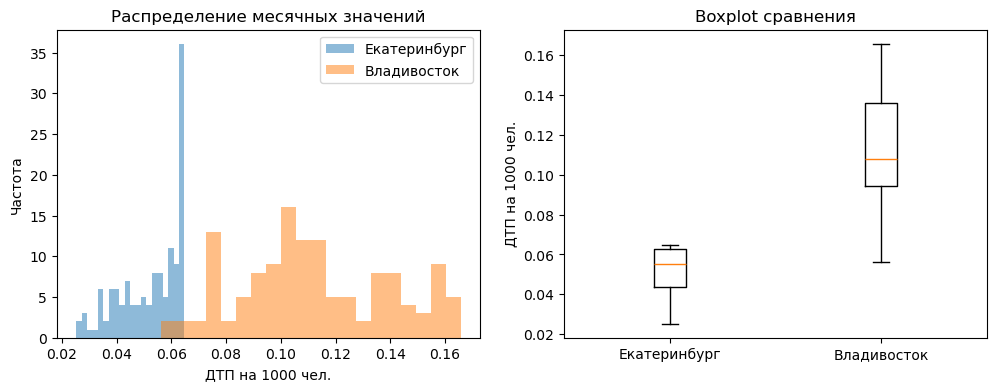

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограммы
axes[0].hist(ekb, bins=20, alpha=0.5, label='Екатеринбург')
axes[0].hist(vlad, bins=20, alpha=0.5, label='Владивосток')
axes[0].set_xlabel('ДТП на 1000 чел.')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].set_title('Распределение месячных значений')

# Boxplot
bp = axes[1].boxplot([ekb, vlad], tick_labels=['Екатеринбург', 'Владивосток'])
axes[1].set_ylabel('ДТП на 1000 чел.')
axes[1].set_title('Boxplot сравнения')

plt.show()

In [72]:
# используем U-критерий Манна-Уитни (распределения не нормальные)
u_stat, p_value = mannwhitneyu(ekb, vlad, alternative='two-sided')

print(f"p-value: {p_value:.6f}")
print(f"Уровень значимости α = 0.05")

if p_value < 0.05:
    print("ОТВЕРГАЕМ H0: Различие статистически значимо")
else:
    print("НЕ ОТВЕРГАЕМ H0: Статистически значимого различия нет")

p-value: 0.000000
Уровень значимости α = 0.05
ОТВЕРГАЕМ H0: Различие статистически значимо


**Вывод** между Екатеринбургом и Владивостоком существует статистически значимое различие в среднем количестве ДТП на 1000 человек населения в месяц.

**Гипотеза 3**

H0: Средние значения степени тяжести пострадавшего одинаково среди пристёгнутых и непристёгнутых (ремень не влияет на тяжесть травмы).

H1: Тяжесть травмы статистически значимо различается  у пристегнутых и непристёгнутых.

Уровень стат. значимости 0,05. Используем U-критерий Манна-Уитни.


In [73]:
uch_corr.groupby('safety_belt_group')['injury_type_group'].mean()

safety_belt_group
0    0.707666
1    0.397078
Name: injury_type_group, dtype: float64

In [74]:
belt_0 = uch_clean2[uch_clean2['safety_belt_group'] == 0]['injury_type_group']
belt_1 = uch_clean2[uch_clean2['safety_belt_group'] == 1]['injury_type_group']

u, p = mannwhitneyu(belt_0, belt_1, alternative='two-sided')
print(f"p-value = {p:.5f}. Отвергаем H0")

p-value = 0.00000. Отвергаем H0


**Вывод**: есть статистически значимое различие в степени тяжести травм у пристегнутых и непристегнутых ремнем безопасности людей. При этом слабая корреляция  (-0,25) означает, что, хотя различие существует, оно не очень сильное; есть много других факторов, влияющих на тяжесть травмы.

### Итоговый вывод по анализу данных

- проанализированы основные статистические показатели ДТП за период 2015-2025 гг. по г. Екатеринбург и Владивосток. Следует отметить общую положительную тенденцию снижения количества ДТП в обоих городах .
- количество погибших в ДТП в Екатеринбурге растет с 2019г, в отличие от Владивостока, где стабильное снижение (с 2019), за исключением одного года (2024), когда наблюдался небольшой прирост
- самые популярные виды ДТП  - это столкновение и наезд на пешехода в обоих городах
- в обоих городах месячная динамика схожа: зимние месяцы спад, постепенный рост весной и летом. в Екатеринбурге пик - сентябрь, во Владивостоке - октябрь, далее резкий спад в ноябре. Вероятные причины роста ДТП летом: рост трафика на трассах (поездки в отпуск, на дачу и т.д.), появление новых участников движения (велосипеды, самокаты), рост числа пешеходов. 
- динамика по дням недели также схожа: пик количества ДТП - в пятницу, снижение в выходные (т.к. в выходные стабильно меньше трафик, чем в будние дни)
- количество ДТП в плохую погоду резко снижается, что, скорее всего, обусловлено снижением трафика в плохую погоду, следовательно и ДТП меньше, однако в % отношении общего числа машин на дорогах, эта статистика может быть другой.
- распределение ДТП по категориям осадков (без осадков, слабые, сильные) статистически значимо различается между Екатеринбургом и Владивостоком. Таким образом, распределение ДТП по типам осадков статистически значимо зависит от города. 
- есть статистически значимое различие в степени тяжести травм у пристегнутых и непристегнутых ремнем безопасности людей (у непристегнутых в среднем травмы тяжелее). При этом слабая корреляция (-0,25) означает, что, хотя различие существует, оно не очень сильное; есть много других факторов, влияющих на тяжесть травмы.
- среднее количество ДТП в мес. на 1000 чел. населения статистически значимо отличается между Екатеринбургом и Владивостоком. Среднее: Екб=0.0524, Владивосток=0.1122
